# Northern Shift Guard — Model Notebook
**Team:** NorthMind | **Event:** Cursor Hackathon Sudbury 2026

Steps:
1. Setup & imports
2. Test OpenAI vision on sample images
3. Prompt tuning → stable JSON
4. Nemotron supervisor action (NVIDIA NIM → OpenAI fallback)
5. Export config to backend

In [1]:
# Cell 2 — Load env
import os
from dotenv import load_dotenv
load_dotenv("../.env")

NVIDIA_KEY = os.getenv("NVIDIA_API_KEY")
OPENAI_KEY = os.getenv("OPENAI_API_KEY")

print("NVIDIA key set:", bool(NVIDIA_KEY))
print("OpenAI key set:", bool(OPENAI_KEY))
if not OPENAI_KEY:
    raise RuntimeError("OPENAI_API_KEY is required for vision and fallback reasoning")


NVIDIA key set: True
OpenAI key set: True


In [2]:
# Cell 3 — Load sample images as base64 data URLs
import base64
from pathlib import Path

IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".webp"}

def image_to_data_url(path: str) -> str:
    with open(path, "rb") as f:
        data = base64.b64encode(f.read()).decode()
    ext = Path(path).suffix.lstrip(".").lower()
    mime = "jpeg" if ext in ("jpg", "jpeg") else ext
    return f"data:image/{mime};base64,{data}"

sample_dir = Path("../sample_images")

REAL_IMAGES = {
    "pass_compliant": sample_dir / "pass_compliant.jpg",
    "fail_missing_hardhat": sample_dir / "fail_missing_hardhat.jpg",
    "fatigue_tired_operator": sample_dir / "fatigue_tired_operator.jpg",
}

missing = [name for name, path in REAL_IMAGES.items() if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing real sample images: {missing}")

print("Real test images:")
for name, path in REAL_IMAGES.items():
    print(f"  {name}: {path.name}")

TEST_IMAGE = str(REAL_IMAGES["fail_missing_hardhat"])
print("\nPrimary test image:", TEST_IMAGE)

Real test images:
  pass_compliant: pass_compliant.jpg
  fail_missing_hardhat: fail_missing_hardhat.jpg
  fatigue_tired_operator: fatigue_tired_operator.jpg

Primary test image: ../sample_images/fail_missing_hardhat.jpg


In [3]:
# Cell 4 — System prompt
SYSTEM_PROMPT = """Industrial safety inspector tool for Northern Ontario mining sites.

Inspect this workplace photo for PPE compliance and return ONLY valid JSON in this exact schema:

{
  "hard_hat": "pass" | "fail" | "unclear",
  "hi_vis": "pass" | "fail" | "unclear",
  "fatigue_risk": "low" | "medium" | "high" | "unclear",
  "evidence": ["<specific observation 1>", "<specific observation 2>"],
  "overall_status": "pass" | "fail" | "unclear"
}

Rules:
- hard_hat: pass only if a hard hat is clearly visible on the worker's head
- hi_vis: pass only if high-visibility vest or jacket is visible on the torso
- fatigue_risk: assess visible posture and alertness cues only (not medical diagnosis)
- evidence: 2-4 specific, factual observations about what is visible in the image
- overall_status: fail if either hard_hat or hi_vis is fail; pass only if both pass
- Return ONLY the JSON object. No markdown, no explanation."""

In [4]:
# Cell 5 — Run vision model on all real images
import json
from openai import OpenAI

VISION_MODEL = "gpt-4o-mini"

def run_vision_openai(image_path: str) -> dict:
    data_url = image_to_data_url(image_path)
    client = OpenAI(api_key=OPENAI_KEY)
    response = client.chat.completions.create(
        model=VISION_MODEL,
        messages=[{
            "role": "user",
            "content": [
                {"type": "text", "text": SYSTEM_PROMPT},
                {"type": "image_url", "image_url": {"url": data_url}},
            ],
        }],
        response_format={"type": "json_object"},
        max_tokens=600,
        temperature=0.1,
    )
    message = response.choices[0].message
    if message.refusal:
        raise RuntimeError(f"Vision model refused: {message.refusal}")
    if not message.content:
        raise RuntimeError("Vision model returned empty content")
    return json.loads(message.content)

def run_vision(image_path: str) -> dict:
    result = run_vision_openai(image_path)
    print(f"[Vision] Used: {VISION_MODEL}")
    return result

results = {}
for scenario, path in REAL_IMAGES.items():
    print(f"\n=== {scenario} ({path.name}) ===")
    results[scenario] = run_vision(str(path))
    print(json.dumps(results[scenario], indent=2))

# Keep single-image variables for downstream cells
result = results["fail_missing_hardhat"]
print("\nPrimary result (fail_missing_hardhat):")
print(json.dumps(result, indent=2))



=== pass_compliant (pass_compliant.jpg) ===
[Vision] Used: gpt-4o-mini
{
  "hard_hat": "fail",
  "hi_vis": "fail",
  "fatigue_risk": "medium",
  "evidence": [
    "No hard hat is visible on the worker's head.",
    "No high-visibility vest or jacket is visible on the torso.",
    "The worker is leaning forward while using a jigsaw, indicating potential fatigue."
  ],
  "overall_status": "fail"
}

=== fail_missing_hardhat (fail_missing_hardhat.jpg) ===
[Vision] Used: gpt-4o-mini
{
  "hard_hat": "fail",
  "hi_vis": "fail",
  "fatigue_risk": "low",
  "evidence": [
    "No hard hat is visible on the worker's head.",
    "No high-visibility vest or jacket is visible on the torso.",
    "The worker is smiling and appears alert."
  ],
  "overall_status": "fail"
}

=== fatigue_tired_operator (fatigue_tired_operator.jpg) ===
[Vision] Used: gpt-4o-mini
{
  "hard_hat": "fail",
  "hi_vis": "fail",
  "fatigue_risk": "medium",
  "evidence": [
    "The worker is not wearing a hard hat.",
    "The wo

In [5]:
# Cell 6 — Supervisor action for all scenarios
from openai import OpenAI

NEMOTRON_MODEL = "nvidia/nemotron-mini-4b-instruct"
REASONING_FALLBACK = "gpt-4o-mini"

SAFETY_REF = """Ontario Regulation 854 (Mines and Mining Plants):
- Section 81: Every worker in a mine shall wear protective headgear at all times in areas where there is risk of head injury.
- Section 79: High-visibility apparel required in active work zones and around mobile equipment.
- Fatigue: Workers showing visible signs of fatigue should be assessed before operating heavy machinery."""

SUPERVISOR_PROMPT = """You are a shift supervisor AI for a Northern Ontario mining site.
Given this PPE and fatigue scan, write ONE prioritized action for the supervisor.
Be direct, safety-first. Max 2 sentences.

Scan result:
{scan}

Safety reference:
{ref}

Supervisor action:"""

def get_supervisor_action(scan_result: dict) -> tuple[str, str]:
    prompt = SUPERVISOR_PROMPT.format(
        scan=json.dumps(scan_result, indent=2),
        ref=SAFETY_REF,
    )

    if NVIDIA_KEY:
        try:
            client = OpenAI(
                base_url="https://integrate.api.nvidia.com/v1",
                api_key=NVIDIA_KEY,
            )
            response = client.chat.completions.create(
                model=NEMOTRON_MODEL,
                messages=[{"role": "user", "content": prompt}],
                max_tokens=200,
                temperature=0.3,
            )
            content = response.choices[0].message.content
            if content:
                return content.strip(), "nvidia"
        except Exception as e:
            print(f"[Nemotron] NVIDIA failed: {e} — falling back to OpenAI")

    client = OpenAI(api_key=OPENAI_KEY)
    response = client.chat.completions.create(
        model=REASONING_FALLBACK,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=200,
        temperature=0.3,
    )
    return response.choices[0].message.content.strip(), REASONING_FALLBACK

actions = {}
for scenario, scan in results.items():
    action, provider = get_supervisor_action(scan)
    actions[scenario] = {"action": action, "provider": provider}
    print(f"\n=== {scenario} ===")
    print(f"Provider: {provider}")
    print(action)

action = actions["fail_missing_hardhat"]["action"]
provider = actions["fail_missing_hardhat"]["provider"]



=== pass_compliant ===
Provider: nvidia
Prioritize immediate inspection of the worker's headgear and torso to ensure compliance with Ontario Regulation 854 (Mines and Mining Plants), sections 81 and 79, and address fatigue risk by reassessing the worker before allowing them to operate heavy machinery.

=== fail_missing_hardhat ===
Provider: nvidia
Prioritize immediate enforcement of hard hat and high-visibility vest requirements, ensuring worker safety first.

=== fatigue_tired_operator ===
Provider: nvidia
Prioritize immediate enforcement of hard hat and high-visibility vest/jacket requirements, as indicated by the scan results, to ensure worker safety and adherence to Ontario Regulation 854.


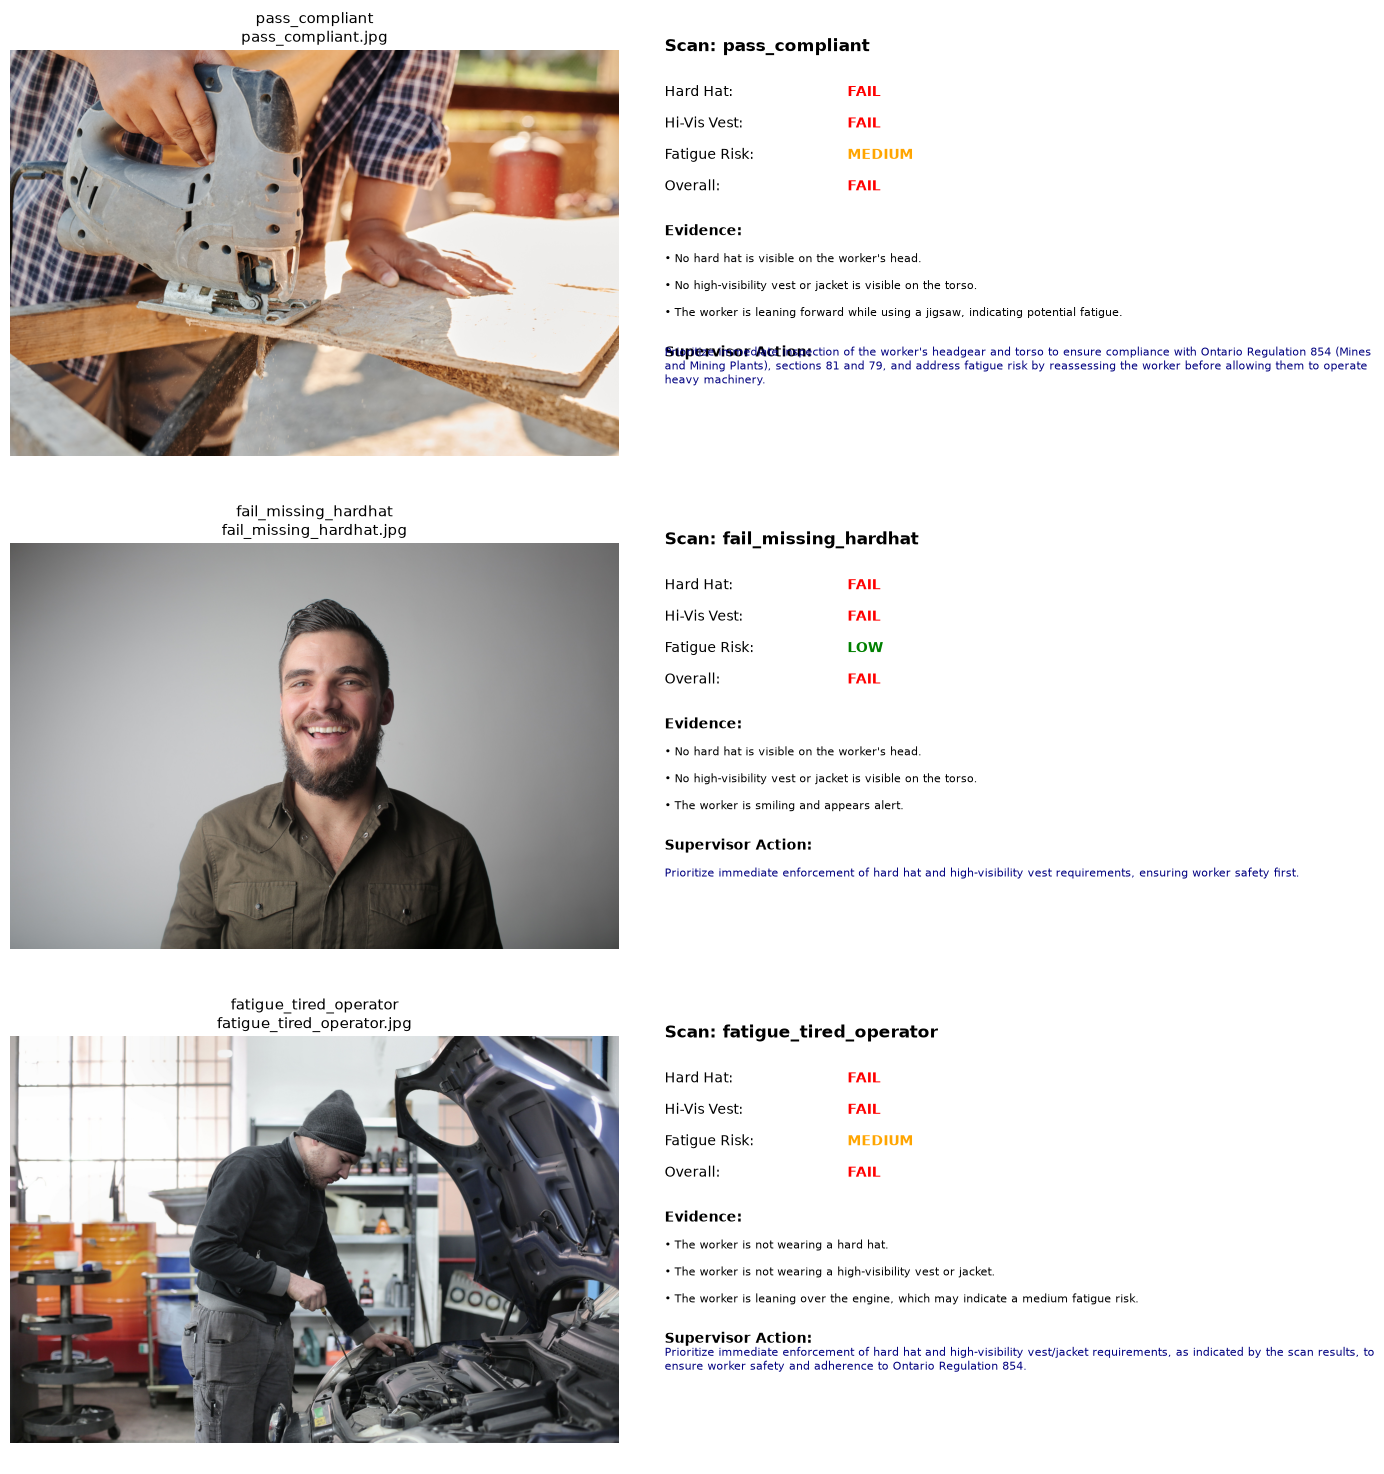

Saved to ../sample_images/last_scan_result.png


In [6]:
# Cell 7 — Visualize all three real-image results
from PIL import Image
import matplotlib.pyplot as plt

STATUS_COLORS = {
    "pass": "green",
    "fail": "red",
    "unclear": "orange",
    "low": "green",
    "medium": "orange",
    "high": "red",
}

fig, axes = plt.subplots(len(REAL_IMAGES), 2, figsize=(14, 5 * len(REAL_IMAGES)))
if len(REAL_IMAGES) == 1:
    axes = [axes]

for row, (scenario, path) in enumerate(REAL_IMAGES.items()):
    scan = results[scenario]
    supervisor = actions[scenario]["action"]

    axes[row][0].imshow(Image.open(path))
    axes[row][0].axis("off")
    axes[row][0].set_title(f"{scenario}\n{path.name}", fontsize=11)

    ax = axes[row][1]
    ax.axis("off")
    y = 0.95
    ax.text(0.05, y, f"Scan: {scenario}", fontsize=12, fontweight="bold", transform=ax.transAxes)
    y -= 0.1

    for label, key in [
        ("Hard Hat", "hard_hat"),
        ("Hi-Vis Vest", "hi_vis"),
        ("Fatigue Risk", "fatigue_risk"),
        ("Overall", "overall_status"),
    ]:
        val = scan.get(key, "unclear")
        color = STATUS_COLORS.get(val, "gray")
        ax.text(0.05, y, f"{label}:", fontsize=10, transform=ax.transAxes)
        ax.text(0.35, y, val.upper(), fontsize=10, color=color, fontweight="bold", transform=ax.transAxes)
        y -= 0.07

    y -= 0.03
    ax.text(0.05, y, "Evidence:", fontsize=10, fontweight="bold", transform=ax.transAxes)
    y -= 0.06
    for ev in scan.get("evidence", []):
        ax.text(0.05, y, f"• {ev}", fontsize=8, wrap=True, transform=ax.transAxes)
        y -= 0.06

    y -= 0.03
    ax.text(0.05, y, "Supervisor Action:", fontsize=10, fontweight="bold", transform=ax.transAxes)
    y -= 0.06
    ax.text(0.05, y, supervisor, fontsize=8, wrap=True, transform=ax.transAxes, color="navy")

plt.tight_layout()
output_path = "../sample_images/last_scan_result.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {output_path}")

In [7]:
# Cell 8 — Export config to backend
import json
from pathlib import Path

config = {
    "vision_model": VISION_MODEL,
    "vision_provider": "openai",
    "nemotron_model": NEMOTRON_MODEL,
    "nemotron_fallback": REASONING_FALLBACK,
    "system_prompt": SYSTEM_PROMPT,
    "notes": "OpenAI gpt-4o-mini for vision; NVIDIA Nemotron mini with OpenAI fallback for supervisor action",
}

config_path = Path("../backend/config/model_config.json")
config_path.write_text(json.dumps(config, indent=2))
print(f"Config exported to {config_path}")


Config exported to ../backend/config/model_config.json
